Library Imports

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
# from sklearn import metrics
import xgboost as xgb
import seaborn as sns
from sklearn.svm import SVC
import imblearn
from imblearn.under_sampling import RandomUnderSampler
from sklearn.neural_network import MLPClassifier
# imports for neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from keras.models import Sequential
from keras.layers import Dense, Dropout
from aequitas.group import Group   # Aequitas is a package for Fairness evaluation

Reading the dataset

In [4]:
# Load Base.csv
df = pd.read_csv('Base.csv')

Data Preprocessing

In [5]:
print(df['device_fraud_count'].value_counts()) # It's 0 for all rows
df = df.drop(['device_fraud_count'], axis=1, errors='ignore') 
print(df)

# to remove null values

df.dropna(inplace=True) 
print(df)

device_fraud_count
0    1000000
Name: count, dtype: int64
        fraud_bool  income  name_email_similarity  prev_address_months_count  \
0                1     0.9               0.166828                         -1   
1                1     0.9               0.296286                         -1   
2                1     0.9               0.044985                         -1   
3                1     0.9               0.159511                         -1   
4                1     0.9               0.596414                         -1   
...            ...     ...                    ...                        ...   
999995           0     0.6               0.192631                         -1   
999996           0     0.8               0.322989                        148   
999997           0     0.8               0.879403                         -1   
999998           0     0.9               0.762112                         -1   
999999           0     0.2               0.697452             

Summary statistics

In [4]:
summary_stats = df.describe().transpose()
print(summary_stats)
# Get a summary of statistical information for each non-numerical column in the DataFrame
df.describe(include=["object", "bool"]).transpose()

                                      count         mean          std  \
fraud_bool                        1000000.0     0.011029     0.104438   
income                            1000000.0     0.562696     0.290343   
name_email_similarity             1000000.0     0.493694     0.289125   
prev_address_months_count         1000000.0    16.718568    44.046230   
current_address_months_count      1000000.0    86.587867    88.406599   
customer_age                      1000000.0    33.689080    12.025799   
days_since_request                1000000.0     1.025705     5.381835   
intended_balcon_amount            1000000.0     8.661499    20.236155   
zip_count_4w                      1000000.0  1572.692049  1005.374565   
velocity_6h                       1000000.0  5665.296605  3009.380665   
velocity_24h                      1000000.0  4769.781965  1479.212612   
velocity_4w                       1000000.0  4856.324016   919.843934   
bank_branch_count_8w              1000000.0   184.3

,count,unique,top,freq
payment_type,1000000,5,AB,370554
employment_status,1000000,7,CA,730252
housing_status,1000000,7,BC,372143
source,1000000,2,INTERNET,992952
device_os,1000000,5,other,342728


In [5]:
# Count the number non-frauds and frauds - class distribution
fraud_values=df['fraud_bool'].value_counts()
# Reset the index of the DataFrame and rename the columns
fraud_values = df['fraud_bool'].value_counts().reset_index()
fraud_values.columns = ['fraud_bool', 'count']
print(fraud_values)

   fraud_bool   count
0           0  988971
1           1   11029


Define custom color palette

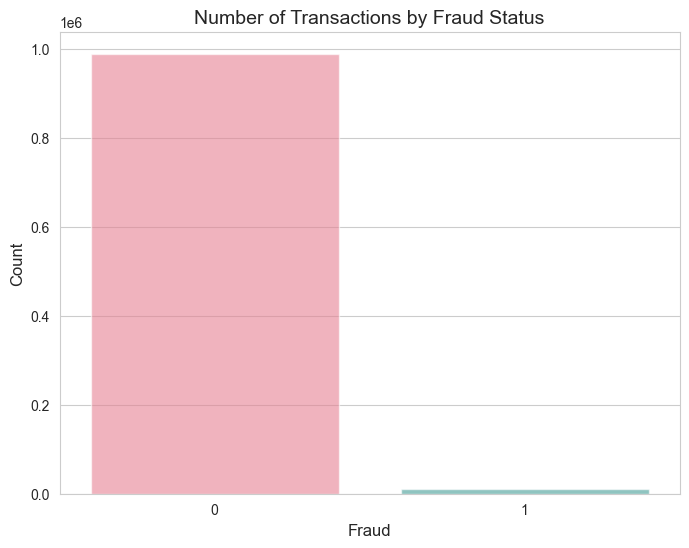

In [6]:
my_palette = sns.color_palette("husl", 2)
sns.set_style("whitegrid")

# Set up plot
plt.figure(figsize=(8, 6))

# Create bar plot
sns.barplot(data=fraud_values, x='fraud_bool', y='count', palette=my_palette, alpha=0.6)

# Customize labels and legend
plt.xlabel("Fraud", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("Number of Transactions by Fraud Status", fontsize=14)

# Display plot
plt.show()

payment_type
AB    370554
AA    258249
AC    252071
AD    118837
AE       289
Name: count, dtype: int64
0.5626956000000002
30.0


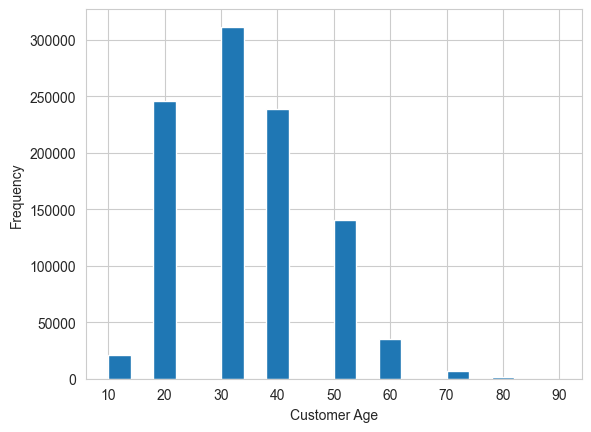

month
3    150936
2    136979
0    132440
4    127691
1    127620
5    119323
6    108168
7     96843
Name: count, dtype: int64

In [7]:
# unique value in payment_type column
value_counts = df['payment_type'].value_counts()
print(value_counts)

# average income

mean_income = df['income'].mean()
print(mean_income)

# customer age
median_age = df['customer_age'].median()
print(median_age)
# Plot a histogram of the customer age
plt.hist(df['customer_age'], bins=20)
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.show()

# monthtly counts
df['month'].value_counts()

Univariate Analysis

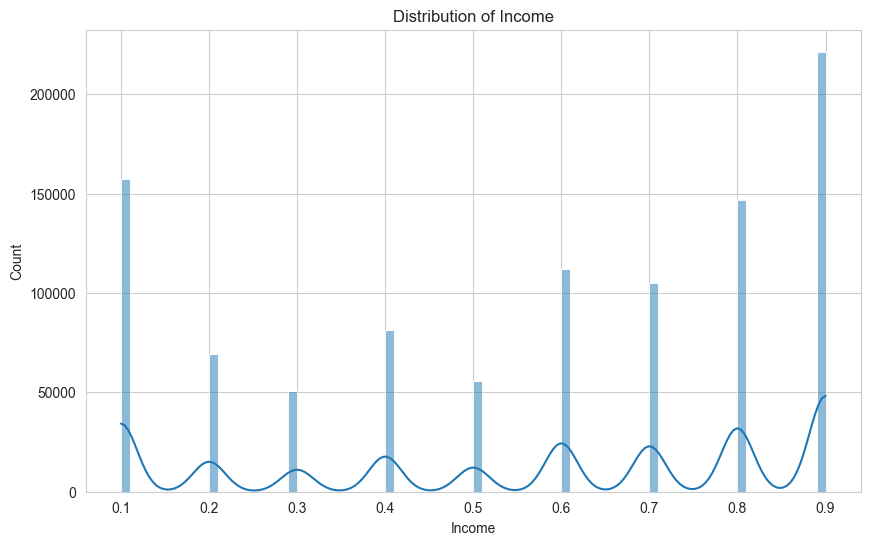

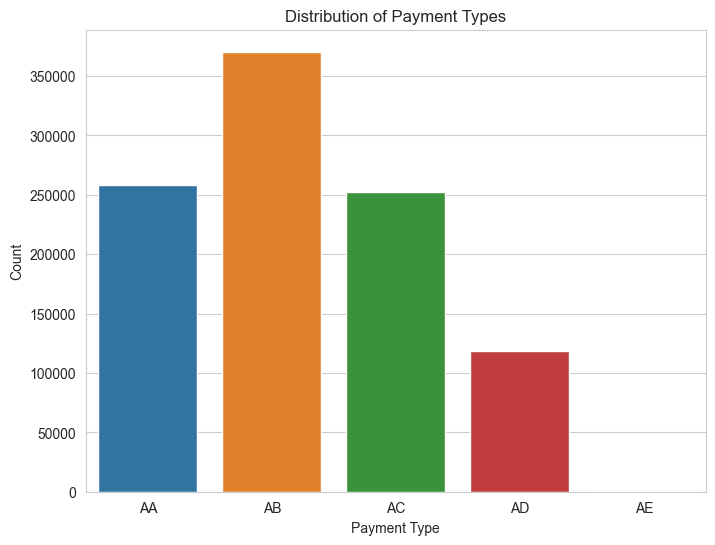

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['income'], kde=True)
plt.xlabel('Income')
plt.ylabel('Count')
plt.title('Distribution of Income')
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='payment_type')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.title('Distribution of Payment Types')
plt.show()

Bivariate Analysis

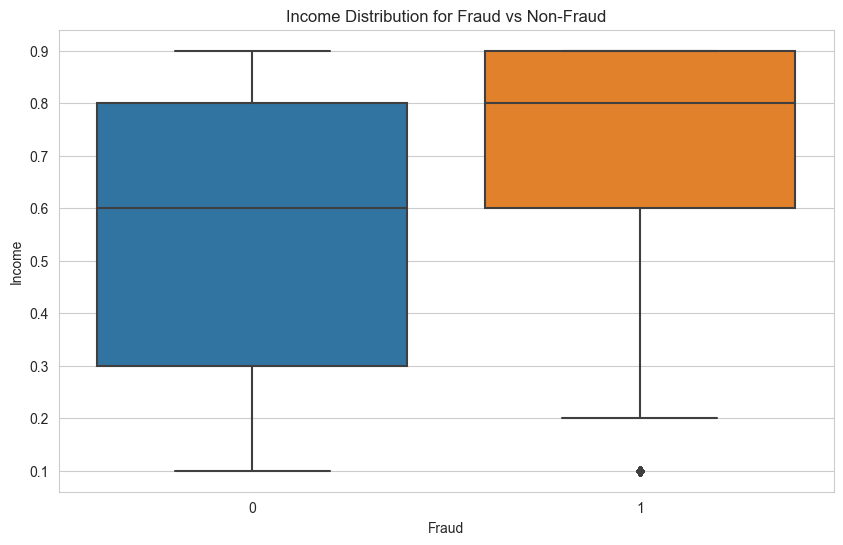

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='fraud_bool', y='income')
plt.xlabel('Fraud')
plt.ylabel('Income')
plt.title('Income Distribution for Fraud vs Non-Fraud')
plt.show()

Heatmap and Correlation Analysis

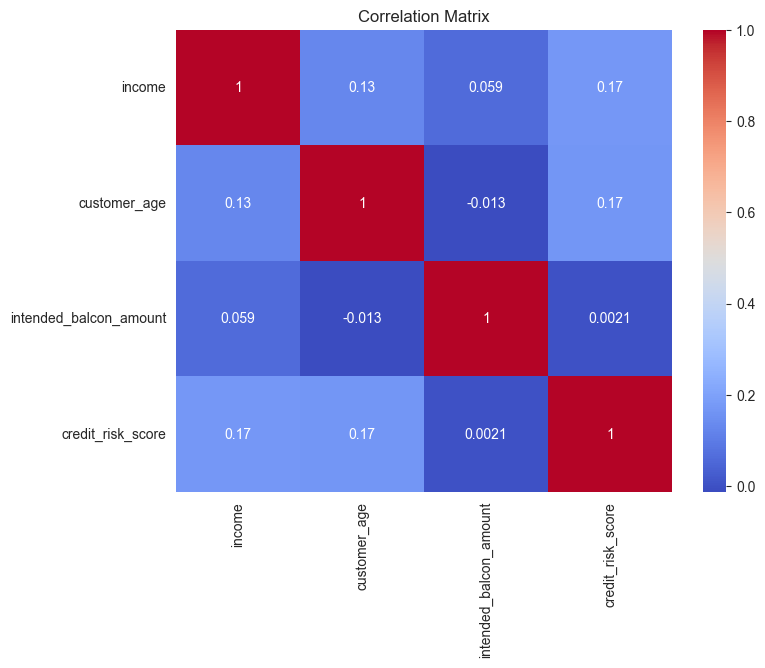

In [10]:
numeric_columns = ['income', 'customer_age', 'intended_balcon_amount', 'credit_risk_score']
numeric_data = df[numeric_columns]
corr_matrix = numeric_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Time-Series Analysis

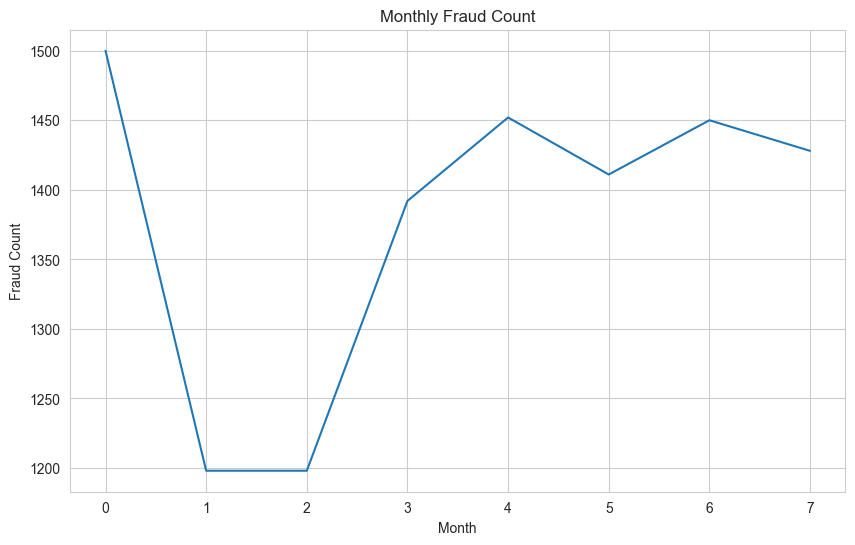

In [11]:
monthly_fraud_counts = df.groupby('month')['fraud_bool'].sum()
plt.figure(figsize=(10, 6))
monthly_fraud_counts.plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Fraud Count')
plt.title('Monthly Fraud Count')
plt.show()

Data Imbalance Analysis

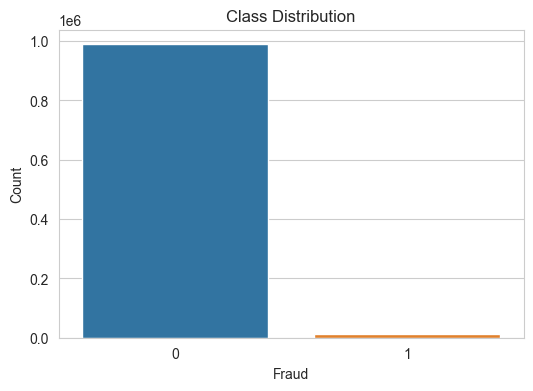

In [12]:
fraud_counts = df['fraud_bool'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.xlabel('Fraud')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

Cross-Tabulations and Pivot Tables

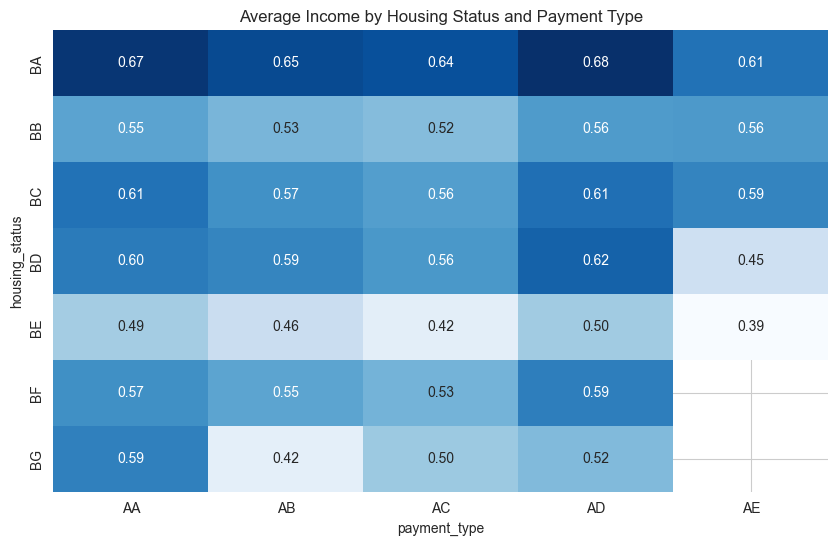

In [13]:
pivot_table = pd.pivot_table(df, values='income', index='housing_status', columns='payment_type', aggfunc=np.mean)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, cmap='Blues', annot=True, fmt='.2f', cbar=False)
plt.title('Average Income by Housing Status and Payment Type')
plt.show()

Fraud transactions based on payment types

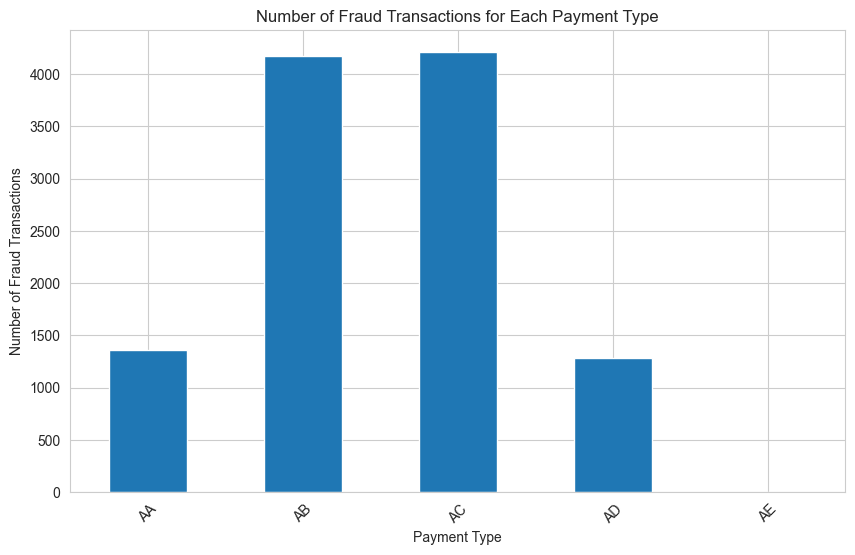

In [14]:
payment_fraud_data = df[['payment_type', 'fraud_bool']]

# Group the data by "payment_type" and calculate the count of fraud transactions for each type
fraud_counts = payment_fraud_data.groupby('payment_type')['fraud_bool'].sum()

# Plot the data as a bar plot
plt.figure(figsize=(10, 6))
fraud_counts.plot(kind='bar')
plt.title('Number of Fraud Transactions for Each Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Fraud Transactions')
plt.xticks(rotation=45)
plt.show()

Data preprocessing for model training

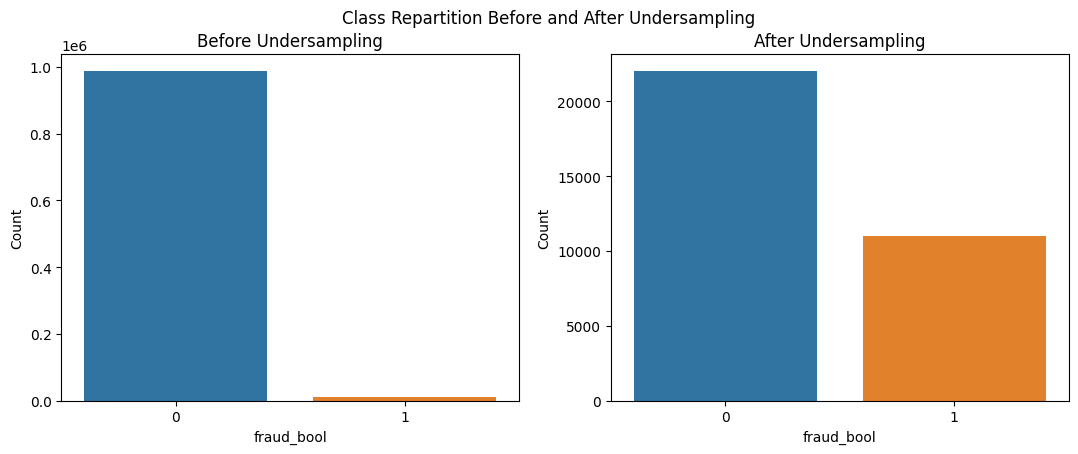

In [11]:
# Define the undersampling strategy
undersample = RandomUnderSampler(sampling_strategy=0.5)

# Define the column names and target variable
cols = df.columns.tolist()
target = "fraud_bool"

# Exclude the target variable from the column list
cols = [c for c in cols if c != target]

# Define X (features) and Y (target)
X = df[cols]
Y = df[target]

# Undersample the dataset
X_under, Y_under = undersample.fit_resample(X, Y)

# Create DataFrames for visualization
df_before = pd.DataFrame({target: Y})
df_after = pd.DataFrame({target: Y_under})

# Visualize the class distribution before and after undersampling
fig, axs = plt.subplots(ncols=2, figsize=(13, 4.5))
sns.countplot(x=target, data=df_before, ax=axs[0])
sns.countplot(x=target, data=df_after, ax=axs[1])

# Set titles and labels for the subplots
fig.suptitle("Class Repartition Before and After Undersampling")
axs[0].set_title("Before Undersampling")
axs[1].set_title("After Undersampling")
axs[0].set_xlabel(target)
axs[1].set_xlabel(target)
axs[0].set_ylabel("Count")
axs[1].set_ylabel("Count")

# Show the plot
plt.show()

X = X_under
Y = Y_under

In [7]:
# Define the column names and target variable
cols = df.columns.tolist()
target = "fraud_bool"

# Exclude the target variable from the column list
cols = [c for c in cols if c != target]

# Define X (features) and Y (target)
X = df[cols]
Y = df[target]

One hot encoding and data splitting

In [12]:
# Split the data into training and testing sets
# X: input features
# Y: target variable
# test_size: the proportion of the dataset to include in the test set
# random_state: the seed used by the random number generator for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

# OneHotEncode on all the categorical features
# Find all the columns containing categorical features

s = (X_train.dtypes == 'object') # list of column-names and whether they contain categorical features
object_cols = list(s[s].index) # All the columns containing these features

# Create an instance of the OneHotEncoder
ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')

# Get one-hot-encoded columns for the training data
ohe_cols_train = pd.DataFrame(ohe.fit_transform(X_train[object_cols]))

# Get one-hot-encoded columns for the test data
ohe_cols_test = pd.DataFrame(ohe.transform(X_test[object_cols]))

# Set the index of the transformed data to match the original data
ohe_cols_train.index = X_train.index
ohe_cols_test.index = X_test.index

# Remove the original categorical columns from the training and test data
num_X_train = X_train.drop(object_cols, axis=1)
num_X_test = X_test.drop(object_cols, axis=1)

# Concatenate the numerical data with the transformed categorical data for the training data
X_train = pd.concat([num_X_train, ohe_cols_train], axis=1)

# Concatenate the numerical data with the transformed categorical data for the test data
X_test = pd.concat([num_X_test, ohe_cols_test], axis=1)

# Convert column names to strings (required in newer versions of scikit-learn)
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# Verify the transformed training data
X_train.head(1)
print(X_train.shape)
print(y_train.shape)

# Print the shape of the encoded training data to get the number of features
print("Number of features after one-hot encoding:", X_train.shape[1])
# With this code, you split your dataset into training and testing sets using train_test_split, and then you perform one-hot encoding on the categorical features for both the training and test data. The code doesn't perform any random undersampling and maintains the original distribution of the data.

(23160, 51)
(23160,)
Number of features after one-hot encoding: 51


c:\Users\devik\OneDrive\Documents\Term 3\Business Project\.venv\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [20]:
df

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,month
0,1,0.9,0.166828,-1,88,50,0.020925,-1.331345,AA,769,...,24,0,500.0,0,INTERNET,3.888115,windows,0,1,7
1,1,0.9,0.296286,-1,144,50,0.005418,-0.816224,AB,366,...,15,0,1500.0,0,INTERNET,31.798819,windows,0,1,7
2,1,0.9,0.044985,-1,132,40,3.108549,-0.755728,AC,870,...,-1,0,200.0,0,INTERNET,4.728705,other,0,1,7
3,1,0.9,0.159511,-1,22,50,0.019079,-1.205124,AB,810,...,31,1,200.0,0,INTERNET,2.047904,linux,0,1,7
4,1,0.9,0.596414,-1,218,50,0.004441,-0.773276,AB,890,...,31,0,1500.0,0,INTERNET,3.775225,macintosh,1,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,0.6,0.192631,-1,104,40,0.030592,-1.044454,AB,804,...,25,0,200.0,0,INTERNET,8.511502,linux,1,1,4
999996,0,0.8,0.322989,148,9,50,1.628119,-1.409803,AC,3306,...,-1,0,200.0,0,INTERNET,8.967865,windows,0,1,4
999997,0,0.8,0.879403,-1,30,20,0.018563,34.692760,AA,1522,...,11,0,200.0,0,INTERNET,8.195531,other,0,1,4
999998,0,0.9,0.762112,-1,189,20,0.015352,94.661055,AA,1418,...,28,0,500.0,0,INTERNET,4.336064,windows,1,1,4


Model 1: Support Vector Machine (SVM)

Accuracy SVM: 0.7078674322554649
Precision SVM: 0.619233776387803
Recall SVM: 0.24711388455538222
F1 Score SVM: 0.3532560214094559


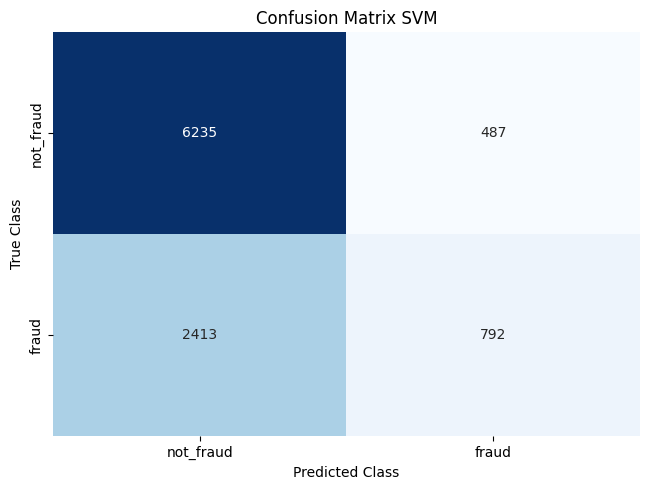

AUC SVM: 0.6961113088974615


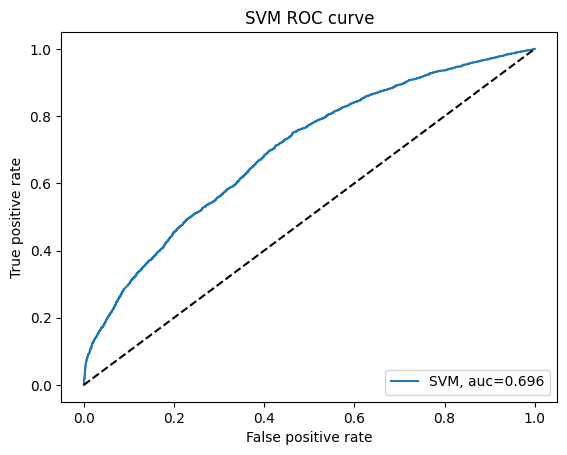

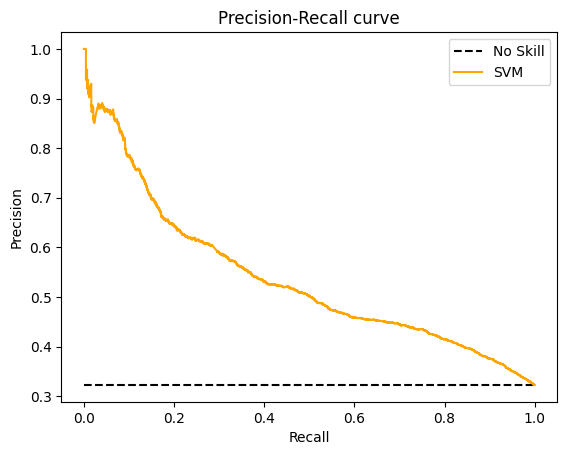

In [51]:
# Create an instance of the SVC model
model = SVC(probability=True, random_state=2)

# Train the model using the training data
svm_model = model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_svm = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_svm)
precision = metrics.precision_score(y_test, y_pred_svm)
recall = metrics.recall_score(y_test, y_pred_svm)
f1_score = metrics.f1_score(y_test, y_pred_svm)

# Print evaluation scores
print("Accuracy SVM:", accuracy)
print("Precision SVM:", precision)
print("Recall SVM:", recall)
print("F1 Score SVM:", f1_score)

# Create a confusion matrix
cm_svm = metrics.confusion_matrix(y_test, y_pred_svm)
cm_svm_df = pd.DataFrame(cm_svm, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

# Plot the confusion matrix
sns.heatmap(cm_svm_df, annot=True, cbar=None, cmap="Blues", fmt='g')
plt.title("Confusion Matrix SVM")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

# Calculate the AUC score
y_pred_svm_proba = model.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = metrics.roc_curve(y_test, y_pred_svm_proba)
auc_svm = metrics.roc_auc_score(y_test, y_pred_svm_proba)
print("AUC SVM:", auc_svm)

# Plot the ROC curve
plt.plot(fpr_svm, tpr_svm, label="SVM, auc={:.3f}".format(auc_svm))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('SVM ROC curve') 
plt.legend(loc=4)
plt.show()

# Plot the Precision-Recall curve
svm_precision, svm_recall, _ = metrics.precision_recall_curve(y_test, y_pred_svm_proba)
no_skill = len(y_test[y_test == 1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill')
plt.plot(svm_recall, svm_precision, color='orange', label='SVM')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()

Model 2: XGboost Classifier

Accuracy XGBoost: 0.6404754709378463
Precision XGBoost: 0.4715358148263997
Recall XGBoost: 0.9407176287051482
F1 Score XGBoost: 0.6281904365038025


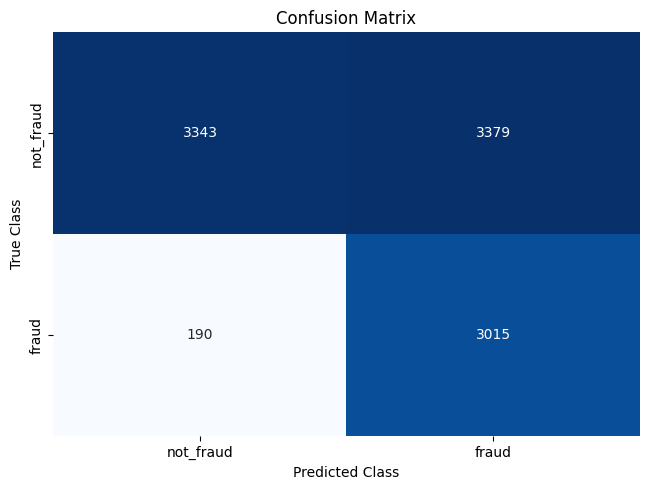

AUC: 0.8650535346019613


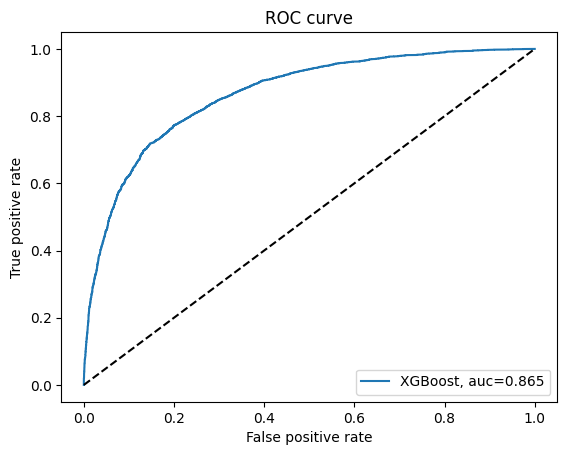

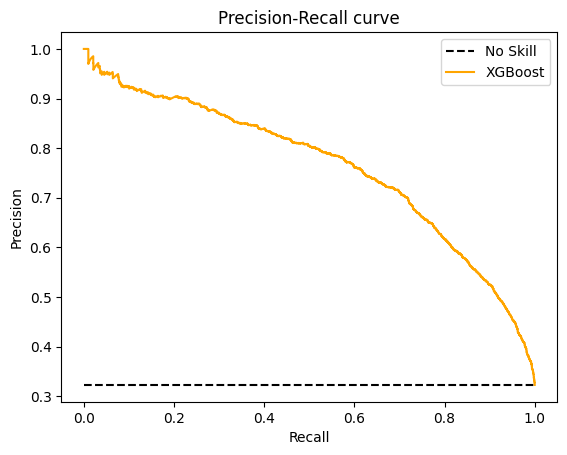

In [53]:
# model = xgb.XGBClassifier(
#     tree_method='gpu_hist', gpu_id=0, 
#     scale_pos_weight=89.67005
# )
# model.fit(X_train, y_train)

# predictions = model.predict_proba(X_test)[:,1]
# evaluate(predictions)

# Create an instance of the XGBClassifier
model = xgb.XGBClassifier(scale_pos_weight=89.67005, random_state=2)

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1_score = metrics.f1_score(y_test, y_pred)

# Print evaluation scores
print("Accuracy XGBoost:", accuracy)
print("Precision XGBoost:", precision)
print("Recall XGBoost:", recall)
print("F1 Score XGBoost:", f1_score)

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

# Plot the confusion matrix
sns.heatmap(cm_df, annot=True, cbar=None, cmap="Blues", fmt='g')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

# Calculate the AUC score
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)

# Plot the ROC curve
plt.plot(fpr, tpr, label="XGBoost, auc={:.3f}".format(auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc=4)
plt.show()

# Plot the Precision-Recall curve
precision, recall, _ = metrics.precision_recall_curve(y_test, y_pred_proba)
no_skill = len(y_test[y_test == 1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill')
plt.plot(recall, precision, color='orange', label='XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()

Model 3: MLP classifier

Accuracy MLP: 0.629193109700816
Precision MLP: 0.37991927346115034
Recall MLP: 0.23494539781591264
F1 Score MLP: 0.29034123770965875


c:\Users\devik\OneDrive\Documents\Term 3\Business Project\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


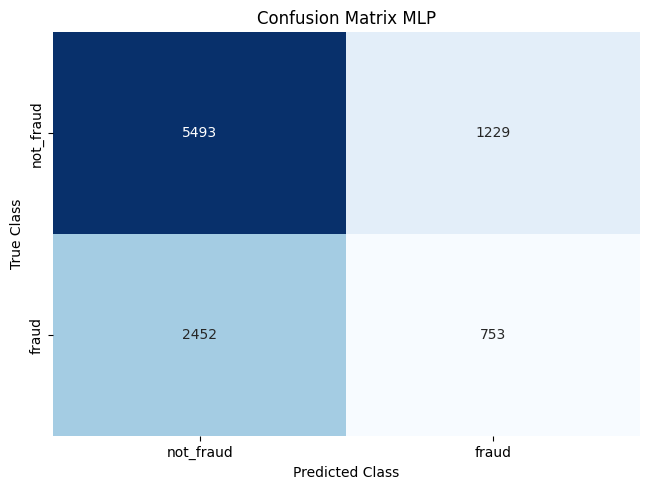

AUC MLP: 0.5463377755580322


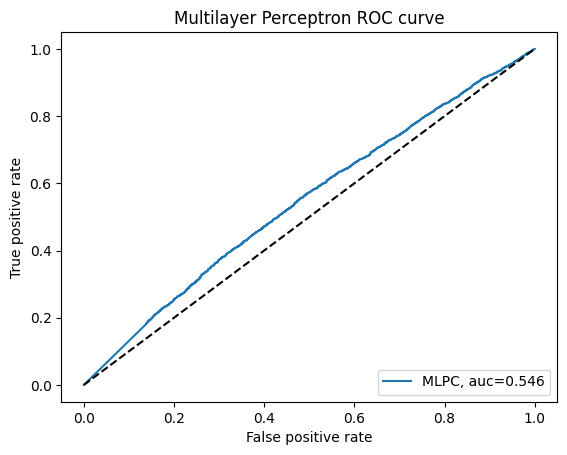

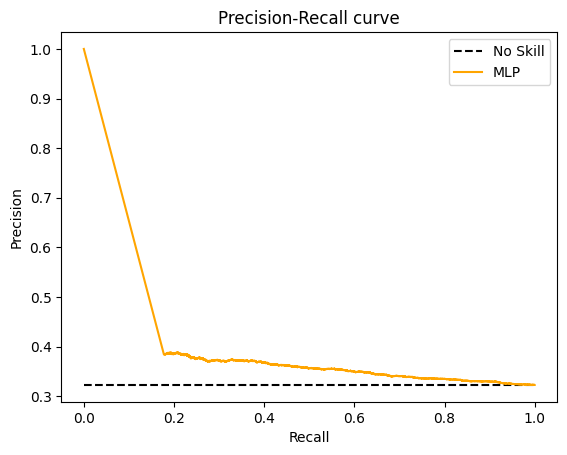

In [54]:
# Create an instance of the MLPClassifier
model = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 100), random_state=2)

# Train the model using the training data
mlp_model = model.fit(X_train, y_train)

# Get the model parameters
model.get_params(deep=True)

# Make predictions on the test data
y_pred_mlp = model.predict(X_test)

# Calculate evaluation metrics
accuracy = metrics.accuracy_score(y_test, y_pred_mlp)
precision = metrics.precision_score(y_test, y_pred_mlp)
recall = metrics.recall_score(y_test, y_pred_mlp)
f1_score = metrics.f1_score(y_test, y_pred_mlp)

# Print evaluation scores
print("Accuracy MLP:", accuracy)
print("Precision MLP:", precision)
print("Recall MLP:", recall)
print("F1 Score MLP:", f1_score)

# Create a confusion matrix
matrix_mlp = confusion_matrix(y_test, y_pred_mlp)
cm_mlp = pd.DataFrame(matrix_mlp, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud'])

# Plot the confusion matrix
sns.heatmap(cm_mlp, annot=True, cbar=None, cmap="Blues", fmt='g')
plt.title("Confusion Matrix MLP")
plt.tight_layout()
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

# Calculate the AUC score
y_pred_mlp_proba = model.predict_proba(X_test)[:, 1]
fpr_mlp, tpr_mlp, _ = metrics.roc_curve(y_test, y_pred_mlp_proba)
auc_mlp = metrics.roc_auc_score(y_test, y_pred_mlp_proba)
print("AUC MLP:", auc_mlp)

# Plot the ROC curve
plt.plot(fpr_mlp, tpr_mlp, label="MLPC, auc={:.3f}".format(auc_mlp))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Multilayer Perceptron ROC curve')
plt.legend(loc=4)
plt.show()

# Plot the Precision-Recall curve
mlp_precision, mlp_recall, _ = metrics.precision_recall_curve(y_test, y_pred_mlp_proba)
no_skill = len(y_test[y_test == 1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill')
plt.plot(mlp_recall, mlp_precision, color='orange', label='MLP')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()

Model 4 : Multilayer Neural Network with Tensorflow/Keras

In [13]:
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

In [14]:
X_train

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,16,17,18,19,20,21,22,23,24,25
96947,0.6,0.119759,90.0,13.0,50.0,0.017611,-0.956232,1626.0,5117.697754,4618.240723,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
753121,0.7,0.052266,-1.0,79.0,30.0,0.014000,-0.441592,1329.0,4798.129395,3743.837402,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
745512,0.9,0.702298,36.0,7.0,30.0,0.024299,32.992630,334.0,9871.045898,4771.825195,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
313496,0.1,0.910685,31.0,14.0,30.0,0.009483,-1.254184,1089.0,6027.612793,5143.421875,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
653530,0.2,0.176329,-1.0,52.0,30.0,0.007889,-0.962705,2247.0,1801.522095,5526.841797,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884129,0.6,0.924558,-1.0,59.0,30.0,0.033368,-1.590816,1100.0,4198.281250,5436.754395,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
873185,0.9,0.307940,-1.0,331.0,60.0,0.012527,-1.252228,2745.0,5364.910156,5020.059082,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
730860,0.1,0.060435,-1.0,36.0,30.0,11.072664,7.878520,1397.0,7868.649902,6860.484863,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
416097,0.6,0.043679,-1.0,64.0,30.0,0.007697,11.953184,1960.0,8785.740234,6419.278809,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [15]:
y_train

96947     1.0
753121    1.0
745512    0.0
313496    0.0
653530    0.0
         ... 
884129    0.0
873185    1.0
730860    0.0
416097    0.0
873677    1.0
Name: fraud_bool, Length: 23160, dtype: float32

In [26]:
# Keras model using dropout and batch normalization
model = keras.Sequential([
    keras.layers.BatchNormalization(input_shape=[X_train.shape[1]]),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

metrics = [
    'accuracy',tf.metrics.AUC(),tf.metrics.F1Score(),tf.metrics.Precision(),tf.metrics.Recall()
]

model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss="binary_crossentropy",
    metrics=metrics
)

# Use EarlyStopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
    mode='max'
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=5,
    callbacks=[early_stopping],
    verbose=1,
    validation_split=0.15
)

history_dict = history.history

Epoch 1/50
3938/3938 [==============================] - 40s 9ms/step - loss: 0.5791 - accuracy: 0.7078 - auc_3: 0.7362 - f1_score: 0.5050 - precision_3: 0.5762 - recall_3: 0.5107 - val_loss: 0.4615 - val_accuracy: 0.7948 - val_auc_3: 0.8564 - val_f1_score: 0.5052 - val_precision_3: 0.6972 - val_recall_3: 0.6942
Epoch 2/50
3938/3938 [==============================] - 36s 9ms/step - loss: 0.5263 - accuracy: 0.7466 - auc_3: 0.7861 - f1_score: 0.5050 - precision_3: 0.6456 - recall_3: 0.5540 - val_loss: 0.4549 - val_accuracy: 0.7971 - val_auc_3: 0.8547 - val_f1_score: 0.5052 - val_precision_3: 0.7041 - val_recall_3: 0.6891
Epoch 3/50
3938/3938 [==============================] - 36s 9ms/step - loss: 0.5049 - accuracy: 0.7597 - auc_3: 0.8039 - f1_score: 0.5050 - precision_3: 0.6679 - recall_3: 0.5740 - val_loss: 0.4597 - val_accuracy: 0.7994 - val_auc_3: 0.8566 - val_f1_score: 0.5052 - val_precision_3: 0.7158 - val_recall_3: 0.6738
Epoch 4/50
3938/3938 [==============================] - 37s 9

In [29]:
# Calculate the AUC score
y_pred_keras_proba = model.predict(X_test)
fpr_keras, tpr_keras, _ = roc_curve(y_test, y_pred_keras_proba)
auc_keras = roc_auc_score(y_test, y_pred_keras_proba)

311/311 [==============================] - 1s 2ms/step


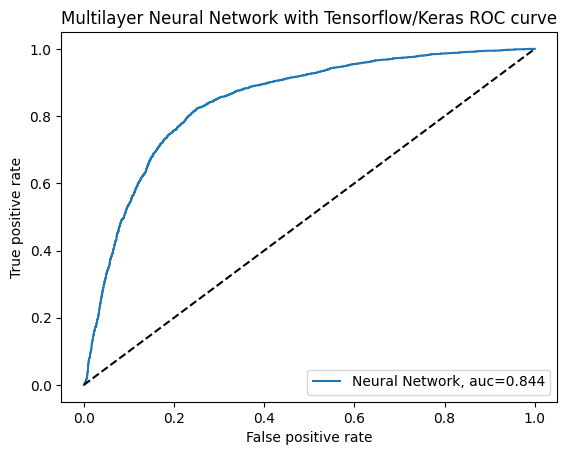

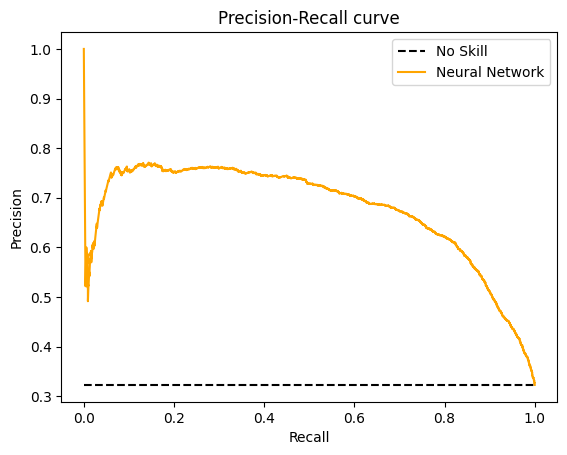

In [31]:
# Plot the ROC curve
plt.plot(fpr_keras, tpr_keras, label="Neural Network, auc={:.3f}".format(auc_keras))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Multilayer Neural Network with Tensorflow/Keras ROC curve')
plt.legend(loc=4)
plt.show()

# Plot the Precision-Recall curve
keras_precision, keras_recall, _ = metrics.precision_recall_curve(y_test, y_pred_keras_proba)
no_skill = len(y_test[y_test == 1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill')
plt.plot(keras_recall, keras_precision, color='orange', label='Neural Network')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()